In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans      # imported for KMeans clustering
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings("ignore")

In [225]:
df = pd.read_csv('house price prediction.csv')
df.drop(columns=['date', 'bedrooms', 'bathrooms', 'waterfront', 'view', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country'], inplace=True)
df.head()

,price,sqft_living,sqft_lot,floors,condition,sqft_above,sqft_basement
0,313000.0,1340,7912,1.5,3,1340,0
1,2384000.0,3650,9050,2.0,5,3370,280
2,342000.0,1930,11947,1.0,4,1930,0
3,420000.0,2000,8030,1.0,4,1000,1000
4,550000.0,1940,10500,1.0,4,1140,800


In [226]:
print(df.shape)

(4600, 7)


In [227]:
X = df.drop(columns=['price'])
y = df['price']

# making a function KMeans learning
wcss = []
def optimise(data, max_k):
    
    for i in range(1, max_k):
        km = KMeans(n_clusters=i, random_state=42)
        km.fit(data)
        wcss.append(km.inertia_)



In [228]:
# scaling the data for better understanding
scaler = StandardScaler()
cols = df.columns
df = pd.DataFrame(scaler.fit_transform(df), columns=cols)

df

,price,sqft_living,sqft_lot,floors,condition,sqft_above,sqft_basement
0,-0.423864,-0.829971,-0.193434,-0.022416,-0.667112,-0.565224,-0.672464
1,3.249598,1.568528,-0.161718,0.906555,2.286416,1.789559,-0.069128
2,-0.372424,-0.217367,-0.080978,-0.951388,0.809652,0.119171,-0.672464
3,-0.234071,-0.144686,-0.190145,-0.951388,0.809652,-0.959621,1.482306
4,-0.003482,-0.206984,-0.121306,-0.951388,0.809652,-0.797222,1.051352
...,...,...,...,...,...,...,...
4595,-0.432437,-0.653458,-0.236689,-0.951388,0.809652,-0.368025,-0.672464
4596,-0.031271,-0.705374,-0.202882,0.906555,-0.667112,-0.426025,-0.672464
4597,-0.239562,0.904009,-0.218462,0.906555,-0.667112,1.371962,-0.672464
4598,-0.618268,-0.051238,-0.229164,-0.951388,-0.667112,-0.878421,1.525401


In [229]:
optimise(df[['price']], 11)
wcss


[4599.999999999998,
 2466.455428283136,
 1354.4538185930207,
 886.6452490430452,
 521.5609182213732,
 352.9005104942334,
 242.4854645784499,
 188.41028840958566,
 145.55440321709335,
 112.92484970866929]

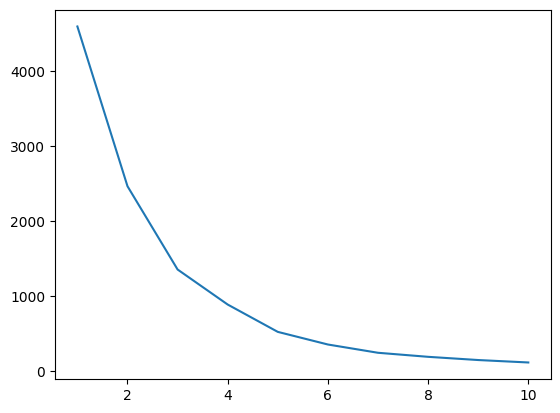

In [230]:
# plotting the wcss graph
plt.plot(range(1, 11), wcss)
plt.show()

In [231]:
km = KMeans(n_clusters=3)
ans = pd.DataFrame(km.fit_predict(df))

print(np.unique(km.labels_))
print(km.labels_[1])
ans

[0 1 2]
2


,0
0,1
1,2
2,1
3,1
4,1
...,...
4595,1
4596,0
4597,0
4598,1


<Figure size 1800x400 with 0 Axes>

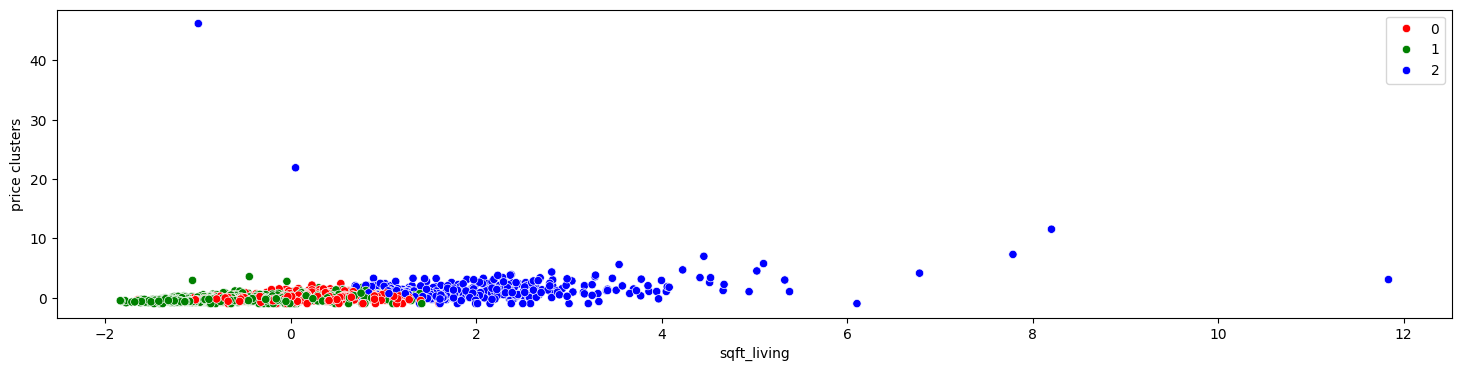

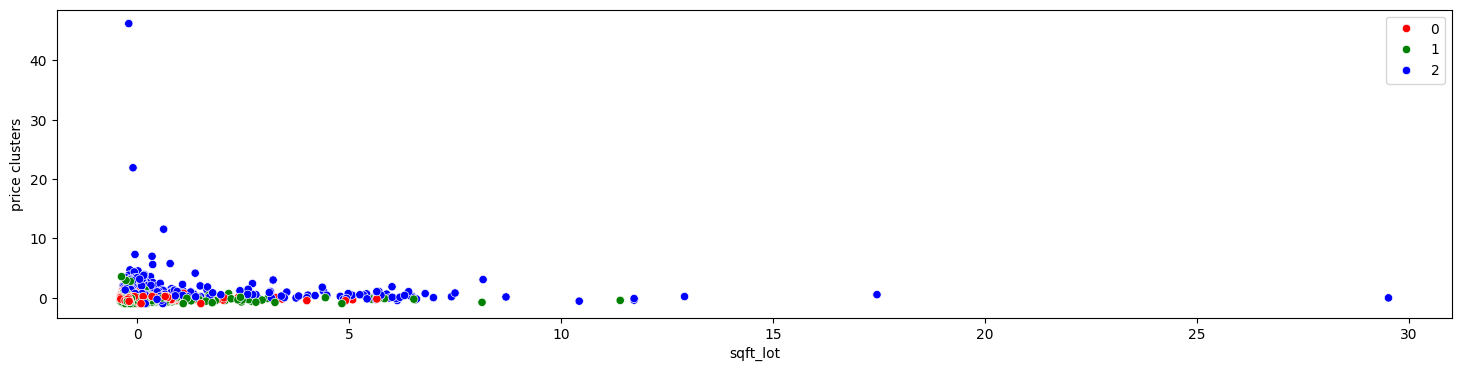

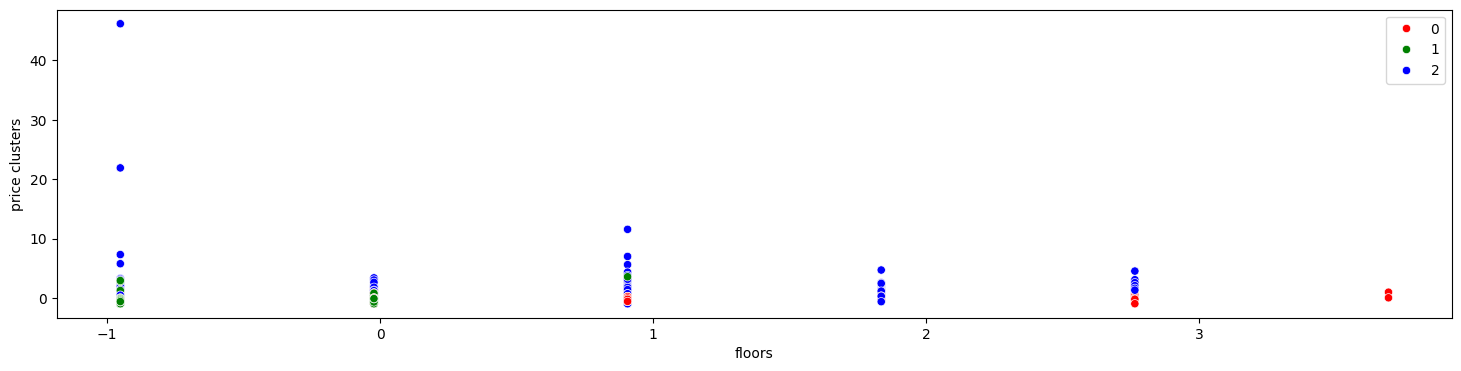

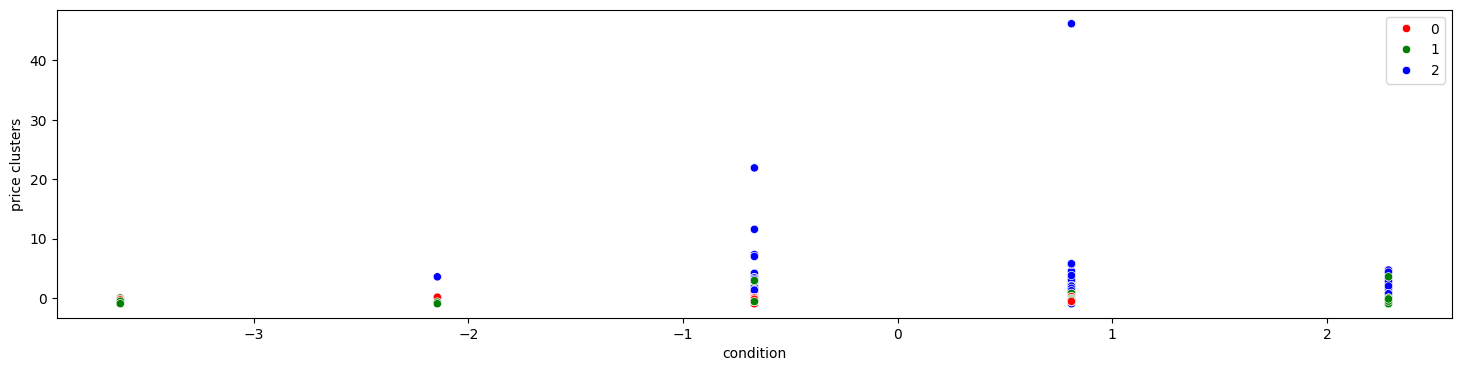

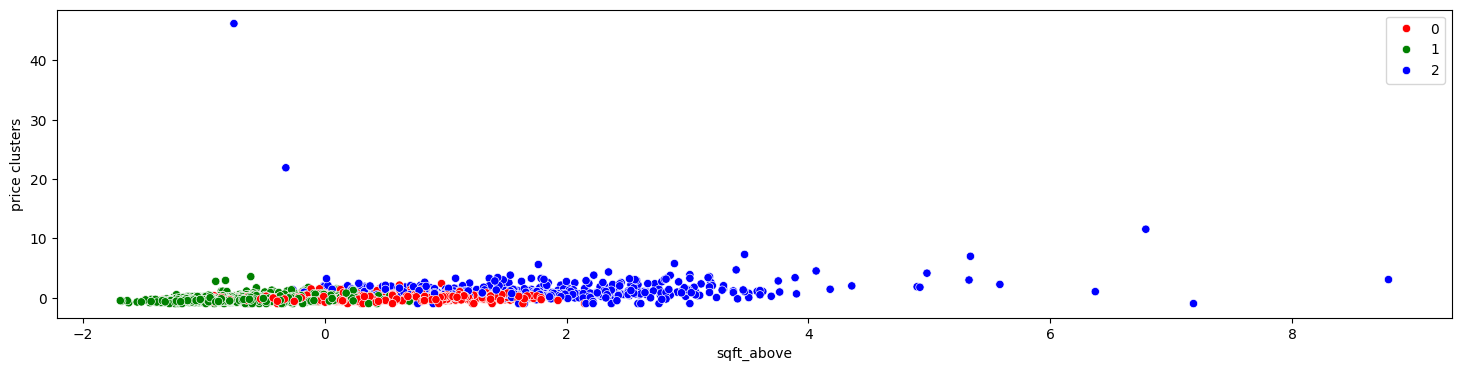

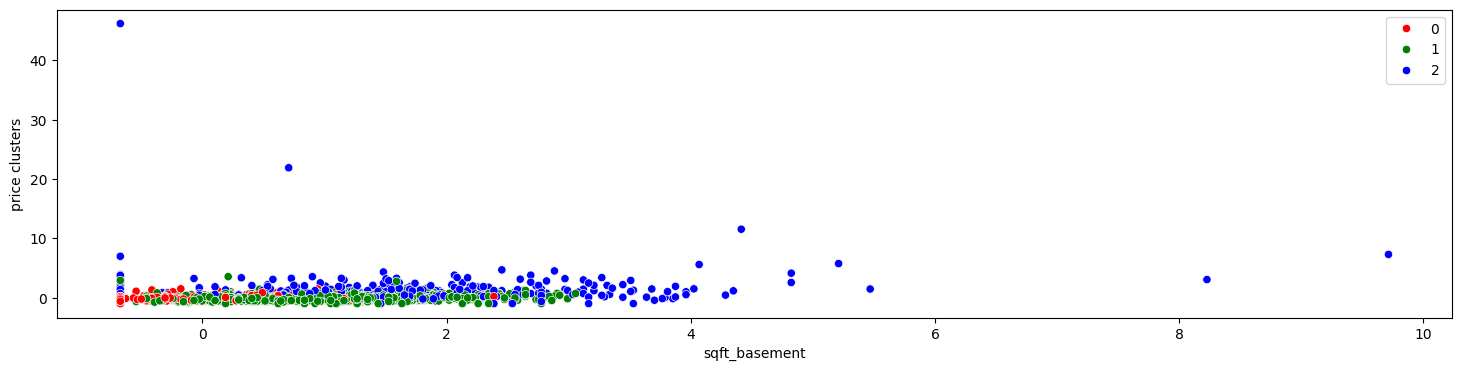

In [241]:
for cols in df.columns:
    plt.figure(figsize=(18,4))
    if cols == 'price':
        continue
    
    sns.scatterplot(x=df[cols], y=df['price'], hue=ans.iloc[:, 0], palette=['r','g', 'b'])      # keep in mind, for plotting hue, the passed parameter must be of 1 dimensional 
    plt.xlabel(cols)
    plt.ylabel('price clusters')
    plt.legend()
    plt.show()